In [95]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [141]:
data_train = pd.read_csv("feature-engineering-train.csv")
data_test = pd.read_csv("feature-engineering-test.csv")

X_train, y_train = data_train.drop(columns=["label"]), data_train["label"]
X_test, y_test = data_test.drop(columns=["label"]), data_test["label"]

X = pd.concat((X_train, X_test), axis=0)
y = pd.concat((y_train, y_test), axis=0)

In [97]:
from functools import reduce

binary_columns = [col for col in X.columns if col.startswith("B")]
discrete_columns = [col for col in X.columns if col.startswith("D")]
float_columns = [col for col in X.columns if col.startswith("F")]
object_columns = [col for col in X.columns if col.startswith("O")]

columns = reduce(
    np.union1d,
    (
        binary_columns,
        discrete_columns,
        float_columns,
        object_columns,
    ),
)
np.setdiff1d(X.columns, columns)

array([], dtype=object)

In [98]:
X = X.drop(columns=object_columns)
X_train = X_train.drop(columns=object_columns)
X_test = X_test.drop(columns=object_columns)

# 1. Feature Selection

## 1.1. Mutual Information for Binary features

In [99]:
from sklearn.feature_selection import mutual_info_regression

mi = mutual_info_regression(X_train, y_train)
mi = pd.Series(mi, index=X_train.columns).sort_values(ascending=False)
mi

DLineOfCode                 0.591568
DNoOfImage                  0.536230
DNoOfExternalRef            0.532420
DNoOfSelfRef                0.515339
DNoOfJS                     0.492646
DLargestLineLength          0.488205
DNoOfCSS                    0.446165
BHasSocialNet               0.389707
BHasCopyrightInfo           0.325636
BHasDescription             0.281754
BHasSubmitButton            0.189653
DNoOfEmptyRef               0.175010
DNoOfiFrame                 0.171759
FTLD                        0.169971
BIsHTTPS                    0.165372
BIsResponsive               0.164344
FDomainEntropy              0.150438
BHasFavicon                 0.148937
BHasHiddenFields            0.148055
BHasDomainTitleMatch        0.144657
FURLCharProb                0.138223
BHasTitle                   0.128622
BHasURLTitleMatch           0.119022
FAlphabetRatioInDomain      0.118779
DNoOfDigitsInDomain         0.101795
DNoOfTokensInDomain         0.096514
DDomainLength               0.088211
B

In [100]:
select_binary_columns = [col for col in mi.index if col.startswith("B")][:4]
select_binary_columns

['BHasSocialNet', 'BHasCopyrightInfo', 'BHasDescription', 'BHasSubmitButton']

Based on the results of MI regression, the most important binary features are

- `HasSocialNet`
- `HasCopyrightInfo`
- `HasDescription`
- `HasSubmitButton`

## 1.2. Anova for floating point features

**Note:** We need to check for normality to apply ANOVA.

In [101]:
from sklearn.feature_selection import f_classif

F, pvals = f_classif(X[float_columns], y.values)

pd.DataFrame(
    {
        "feature": float_columns,
        "F": F,
        "pval": pvals,
    }
).sort_values("pval")

,feature,F,pval
0,FTLD,89186.923651,0.0
1,FURLCharProb,64607.226549,0.0
2,FAlphabetRatioInDomain,19142.071368,0.0
3,FDomainEntropy,18619.369205,0.0


All of the columns have very low p-values (nearly zero). So, we keep all of the floating point columns.

## 1.3. Wrapper Method: RFE

**Note:** Takes too long.

In [102]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
rfe = RFE(model, step=1)
rfe.fit(X_train, y_train)
pd.Series(rfe.ranking_, index=X_train.columns).sort_values(ascending=True)

/home/byron/Development/School/2025-1/STAT411/Phishing-URL--Website--Detection/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/home/byron/Development/School/2025-1/STAT411/Phishing-URL--Website--Detection/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence

BIsDomainIP                  1
FTLD                         1
FURLCharProb                 1
DTLDLength                   1
BHasObfuscation              1
DNoOfSubDomain               1
DNoOfObfuscatedChar          1
BIsHTTPS                     1
BHasURLRedirect              1
BHasTitle                    1
BHasFavicon                  1
BHasHiddenFields             1
BHasSocialNet                1
BHasSubmitButton             1
DNoOfPopup                   1
BHasDescription              1
BHasCopyrightInfo            1
BHasPasswordField            1
DNoOfHyphensInDomain         1
BHasDomainTitleMatch         1
BHasCharContinuation         1
FAlphabetRatioInDomain       1
DNoOfDigitsInDomain          1
BHasURLTitleMatch            2
BHasHyphenInDomain           3
BBank                        4
DNoOfImage                   5
FDomainEntropy               6
DNoOfSelfRef                 7
BRobots                      8
DNoOfJS                      9
BHasExternalFormSubmit      10
DNoOfTok

In [103]:
X_train.columns[rfe.get_support()]

Index(['BIsDomainIP', 'FTLD', 'FURLCharProb', 'DTLDLength', 'DNoOfSubDomain',
       'BHasObfuscation', 'DNoOfObfuscatedChar', 'BIsHTTPS', 'BHasTitle',
       'BHasFavicon', 'BHasURLRedirect', 'BHasDescription', 'DNoOfPopup',
       'BHasSocialNet', 'BHasSubmitButton', 'BHasHiddenFields',
       'BHasPasswordField', 'BHasCopyrightInfo', 'DNoOfDigitsInDomain',
       'DNoOfHyphensInDomain', 'FAlphabetRatioInDomain',
       'BHasCharContinuation', 'BHasDomainTitleMatch'],
      dtype='object')

## 1.4. Embedded Method: Random Forest

In [104]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_jobs=-1, random_state=0)
rf.fit(X_train, y_train)
importances = pd.Series(
    data=rf.feature_importances_,
    index=X_train.columns,
).sort_values()

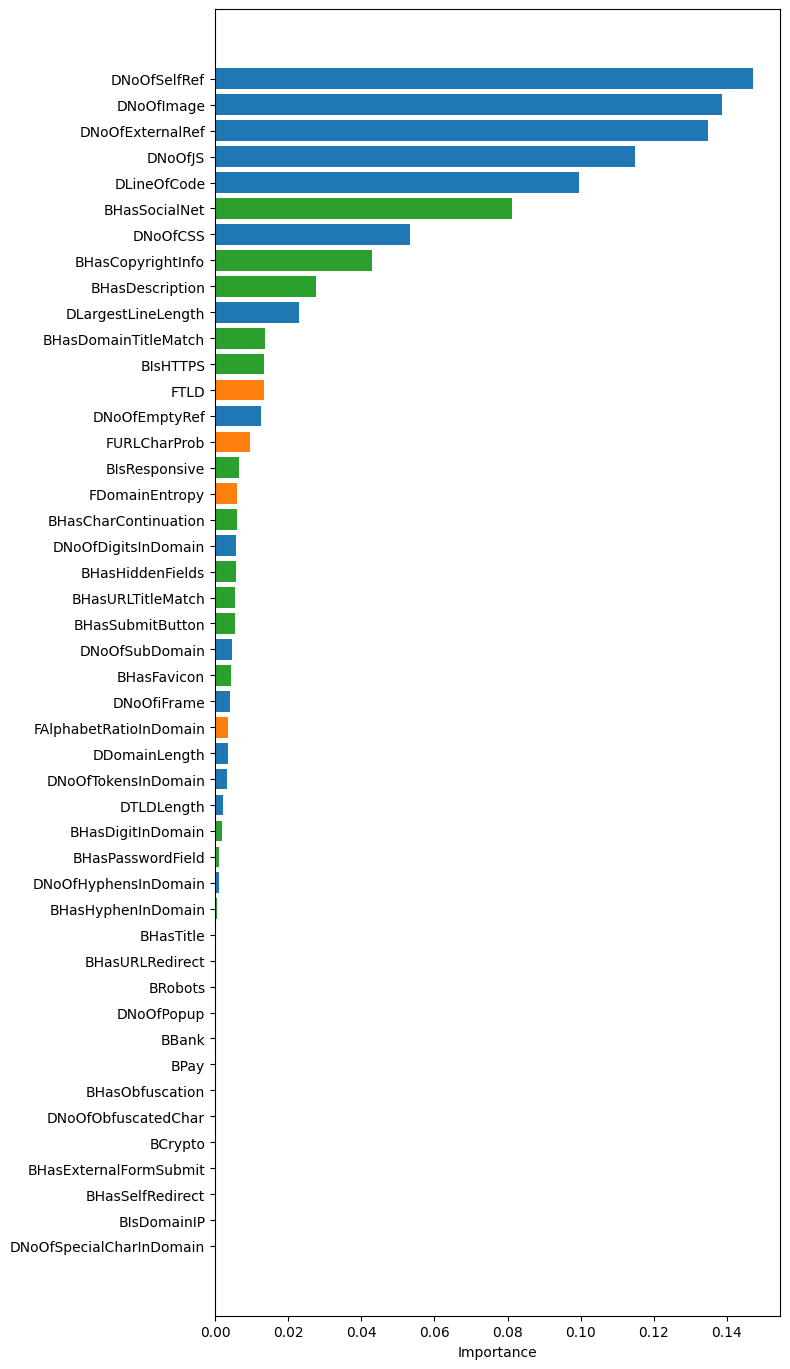

In [105]:
def feature_color(name):
    if name.startswith("D"):
        return "tab:blue"
    if name.startswith("F"):
        return "tab:orange"
    if name.startswith("B"):
        return "tab:green"
    return "gray"


plt.figure(figsize=(8, 0.3 * len(importances)))
plt.barh(
    importances.index,
    importances.values,
    color=[feature_color(f) for f in importances.index]
)
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

## 1.5. L1-Logistic Regression

In [106]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from joblib import Parallel, delayed

Cs = [1.0, 0.5, 0.1, 0.05, 0.01]


def fit_model(C):
    pipe = Pipeline(
        [
            ("scaler", StandardScaler()),
            (
                "clf",
                LogisticRegression(
                    penalty="l1",
                    solver="liblinear",
                    C=C,
                    max_iter=500,
                    random_state=0,
                ),
            ),
        ]
    )
    pipe.fit(X_train, y_train)
    return pipe


models = Parallel(n_jobs=-1, backend="loky")(delayed(fit_model)(C) for C in Cs)
models = dict(zip(Cs, models))

/home/byron/Development/School/2025-1/STAT411/Phishing-URL--Website--Detection/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/byron/Development/School/2025-1/STAT411/Phishing-URL--Website--Detection/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/home/byron/Development/School/2025-1/STAT411/Phishing-URL--Website--Detection/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid t

In [107]:
for C, model in models.items():
    coefs = model.named_steps["clf"].coef_.ravel()
    print(f"{C}: {coefs}")

1.0: [-2.47067437e-01 -1.00474199e+01  1.00108366e+00  9.44415716e-01
 -1.07567898e+00  6.39218664e-01 -4.51617874e-01 -4.43242871e+00
  1.87733459e+00  1.56105870e+00 -8.31053894e+00  1.10327924e+00
  2.64736741e-01 -2.93032700e-02  1.08085557e-01 -2.58911210e-01
 -5.14277842e-02  8.06088988e-01  3.30929308e-01 -4.97575629e-02
 -4.61384706e-03  1.25216882e+00  2.98518728e-01  2.36647285e-01
 -4.32667594e-01 -9.05400099e-02  1.81233346e-01 -1.16016527e-02
  9.17342437e-01  1.99879519e+00  8.37924031e-01  2.08294613e+00
  2.35074441e+00 -5.50317362e-02  1.54695832e+00 -1.34422746e+00
 -1.71013130e-01 -4.02884602e-02 -6.76814590e-01  1.78743758e-01
  1.75784562e-02  5.27708573e-01  9.70631322e-02  1.02803825e+00
 -1.35052949e-01  3.22383717e-01]
0.5: [-2.39856349e-01 -9.04891568e+00  1.02526761e+00  9.22906350e-01
 -1.12412461e+00  6.36297174e-01 -6.17575610e-01 -2.77849568e+00
  1.89993544e+00  1.71640056e+00 -8.81271201e+00  1.24328132e+00
  2.71667410e-01 -7.62468134e-03  1.22796880e-

In [108]:
pd.Series(
    data=models[0.01].named_steps["clf"].coef_.ravel(),
    index=X_train.columns,
).abs().sort_values(ascending=True)

BIsDomainIP                 0.000000
DNoOfObfuscatedChar         0.000000
BRobots                     0.000000
BCrypto                     0.000000
BHasExternalFormSubmit      0.000000
DNoOfiFrame                 0.000000
DNoOfPopup                  0.000000
BHasSelfRedirect            0.000000
FDomainEntropy              0.000000
BHasHyphenInDomain          0.000000
DNoOfSpecialCharInDomain    0.000000
DNoOfEmptyRef               0.000000
BPay                        0.016984
BBank                       0.023621
BIsResponsive               0.038701
DNoOfTokensInDomain         0.072660
BHasObfuscation             0.079503
BHasDigitInDomain           0.105615
BHasURLRedirect             0.150104
DNoOfHyphensInDomain        0.155957
BHasURLTitleMatch           0.171658
FAlphabetRatioInDomain      0.178626
BHasSubmitButton            0.181716
BHasHiddenFields            0.200465
BHasFavicon                 0.220609
DDomainLength               0.259809
BHasPasswordField           0.268160
D

# 2. Scale and Check Variables

## 2.1. Scale variables

In [109]:
from sklearn.preprocessing import StandardScaler



# 3. Model Assumptions

## 3.1. Linearity of Logit

In [110]:
import statsmodels.api as sm

X_bt = X.copy()

for c in float_columns:
    X_bt[f"{c}_log"] = X[c] * np.log(X[c].clip(lower=1e-6))

X_bt = sm.add_constant(X_bt)
model = sm.Logit(y, X_bt).fit(disp=0)

bt_terms = [c for c in X_bt.columns if c.endswith("_log")]
model.pvalues[bt_terms]

/home/byron/Development/School/2025-1/STAT411/Phishing-URL--Website--Detection/.venv/lib/python3.13/site-packages/statsmodels/discrete/discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
/home/byron/Development/School/2025-1/STAT411/Phishing-URL--Website--Detection/.venv/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


FTLD_log                      2.835285e-02
FURLCharProb_log              8.946598e-01
FAlphabetRatioInDomain_log    3.073186e-26
FDomainEntropy_log            8.121487e-31
dtype: float64

In [111]:
model.pvalues[bt_terms] < 0.05

FTLD_log                       True
FURLCharProb_log              False
FAlphabetRatioInDomain_log     True
FDomainEntropy_log             True
dtype: bool

All p-values are significant ($\alpha = 0.05$), except for `URLCharProb`.

## 3.2. No Perfect Multicollinearity

In [112]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X_ = X.drop(columns=["FAlphabetRatioInDomain"])

X_vif = sm.add_constant(X_)

vif = pd.Series(
    [variance_inflation_factor(X_vif.values, i)
     for i in range(1, X_vif.shape[1])],
    index=X_.columns
)

vif.sort_values(ascending=False)

DNoOfHyphensInDomain        4.572469
DDomainLength               4.148537
BHasDomainTitleMatch        4.055206
BHasURLTitleMatch           3.989590
DNoOfTokensInDomain         3.617471
BHasHyphenInDomain          3.270653
FDomainEntropy              3.259636
DNoOfDigitsInDomain         2.540251
BHasSocialNet               2.489059
BHasCharContinuation        2.475879
DNoOfSelfRef                2.274784
DNoOfSubDomain              2.216935
BHasCopyrightInfo           2.185245
DNoOfExternalRef            2.063275
BHasDigitInDomain           2.031859
BHasSubmitButton            1.980220
BHasDescription             1.940785
FURLCharProb                1.884786
BIsHTTPS                    1.818069
BIsResponsive               1.792139
BHasHiddenFields            1.740538
BHasTitle                   1.531219
BHasSelfRedirect            1.451481
FTLD                        1.451353
DTLDLength                  1.442969
BHasFavicon                 1.419775
BHasURLRedirect             1.418080
D

We have some problematic columns:
- `FAlphabetRatioInDomain`
- `DNoOfDigitsInDomain`
- `DDomainLength`

All of these features and some other features related to domain have high VIF.

# 4. Transformation

Apply Box-Cox to strictly positive variables and Yeo-Johnson to the rest.

In [ ]:
numeric_columns = np.union1d(discrete_columns, float_columns)

q = (X_train[numeric_columns] <= 0).sum() == 0
box_cox_columns = q[q].index
yeo_johnson_columns = q[~q].index

Index(['DDomainLength', 'DLineOfCode', 'DNoOfCSS', 'DNoOfDigitsInDomain',
       'DNoOfEmptyRef', 'DNoOfExternalRef', 'DNoOfHyphensInDomain',
       'DNoOfImage', 'DNoOfJS', 'DNoOfObfuscatedChar', 'DNoOfPopup',
       'DNoOfSelfRef', 'DNoOfSpecialCharInDomain', 'DNoOfSubDomain',
       'DNoOfTokensInDomain', 'DNoOfiFrame', 'DTLDLength',
       'FAlphabetRatioInDomain'],
      dtype='object')

In [142]:
from sklearn.preprocessing import PowerTransformer

pt = PowerTransformer(method="box-cox", standardize=True)

pt.fit(X_train[box_cox_columns])

X_train[box_cox_columns] = pd.DataFrame(pt.transform(X_train[box_cox_columns]), columns=box_cox_columns, index=X_train.index)
X_test[box_cox_columns] = pd.DataFrame(pt.transform(X_test[box_cox_columns]), columns=box_cox_columns, index=X_test.index)

pt = PowerTransformer(method="yeo-johnson", standardize=True)

pt.fit(X_train[yeo_johnson_columns])

X_train[yeo_johnson_columns] = pd.DataFrame(pt.transform(X_train[yeo_johnson_columns]), columns=yeo_johnson_columns, index=X_train.index)
X_test[yeo_johnson_columns] = pd.DataFrame(pt.transform(X_test[yeo_johnson_columns]), columns=yeo_johnson_columns, index=X_test.index)

In [ ]:
X_train.to_csv("feature-engineering-transform-train.csv", index=False)
X_test.to_csv("feature-engineering-transform-test.csv", index=False)

# 5. PCA

In [148]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

X_train_ = X_train.select_dtypes(exclude=["object"])

X_train_scaled = StandardScaler().fit_transform(X_train_)
pca = PCA(random_state=0)
X_train_pca = pca.fit_transform(X_train_scaled)

In [150]:
pca.explained_variance_ratio_

array([0.27545572, 0.08131098, 0.04648434, 0.04309698, 0.03790952,
       0.03714822, 0.03411467, 0.03006261, 0.02633389, 0.02335592,
       0.0223776 , 0.0216925 , 0.0213453 , 0.02046113, 0.01974692,
       0.01818171, 0.01779043, 0.01618408, 0.01530956, 0.01495805,
       0.01414179, 0.01353304, 0.01315315, 0.01277603, 0.0120961 ,
       0.01087047, 0.01066631, 0.00986982, 0.00870057, 0.0086344 ,
       0.00834813, 0.00818841, 0.00744201, 0.00648084, 0.00548986,
       0.0051739 , 0.00351121, 0.00306873, 0.00266444, 0.00256017,
       0.00235296, 0.00222979, 0.0021438 , 0.00132798, 0.00066267,
       0.00059333])

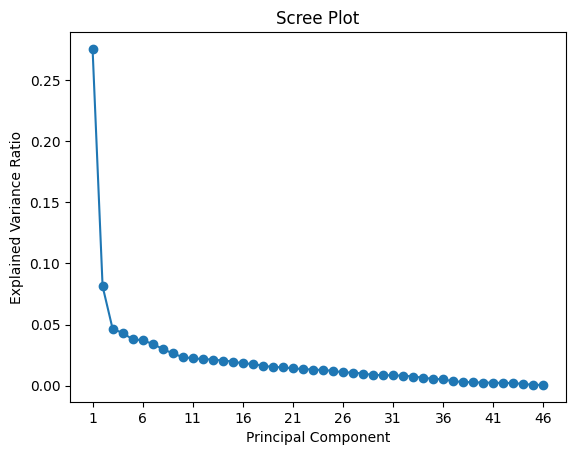

In [152]:
evr = pca.explained_variance_ratio_
n = len(evr)

plt.figure()
plt.plot(np.arange(1, n + 1), evr, marker='o')
plt.title("Scree Plot")
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.xticks(np.arange(1, n + 1, 5))
plt.show()

# t-SNE and UMAP

In [154]:
from sklearn.manifold import TSNE # Import the TSNE class

X_train_ = X_train.select_dtypes(exclude=["object"])

tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X_train_)

plt.figure(figsize=(8, 5))
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y_train, cmap='coolwarm', edgecolors='k')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.title('t-SNE Projection of Breast Cancer Data')
plt.show()

KeyboardInterrupt: 